In [1]:
#importing libraries
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import matplotlib.colors as mcolors
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import f1_score, classification_report

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Read csv file into a pandas dataframe
data = pd.read_csv("housing.csv")
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,INLAND,78100
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,INLAND,77100
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,INLAND,92300
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,INLAND,84700


In [3]:
data = data.drop(['longitude', 'latitude'], axis=1)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   housing_median_age  20640 non-null  int64  
 1   total_rooms         20640 non-null  int64  
 2   total_bedrooms      20433 non-null  float64
 3   population          20640 non-null  int64  
 4   households          20640 non-null  int64  
 5   median_income       20640 non-null  float64
 6   ocean_proximity     20640 non-null  object 
 7   median_house_value  20640 non-null  int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 1.3+ MB


In [4]:
data.isnull().sum()   

housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
ocean_proximity         0
median_house_value      0
dtype: int64

In [5]:
mean = data["total_bedrooms"].mean()
data["total_bedrooms"].fillna(mean, inplace = True)
data

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,52,1627,280.0,565,259,3.8462,NEAR BAY,342200
...,...,...,...,...,...,...,...,...
20635,25,1665,374.0,845,330,1.5603,INLAND,78100
20636,18,697,150.0,356,114,2.5568,INLAND,77100
20637,17,2254,485.0,1007,433,1.7000,INLAND,92300
20638,18,1860,409.0,741,349,1.8672,INLAND,84700


In [6]:
data.isnull().sum()

housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
median_house_value    0
dtype: int64

In [7]:
data.head(20)

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,52,1627,280.0,565,259,3.8462,NEAR BAY,342200
5,52,919,213.0,413,193,4.0368,NEAR BAY,269700
6,52,2535,489.0,1094,514,3.6591,NEAR BAY,299200
7,52,3104,687.0,1157,647,3.1200,NEAR BAY,241400
8,42,2555,665.0,1206,595,2.0804,NEAR BAY,226700
9,52,3549,707.0,1551,714,3.6912,NEAR BAY,261100


In [9]:
data.shape

(20640, 8)

In [15]:
def extreme_outliers(df,column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    up = q3 + 3*iqr
    lb = q1 - 3*iqr
    #print(lb,up)
    ext_outliers = df[(df[column]>up) | (df[column]<lb)]
    return ext_outliers

In [16]:
selected_columns = data.select_dtypes(include = ["number"])
for col in selected_columns:
    ext_out = extreme_outliers(data,col)
    if len(ext_out)>0:
        print("Extreme outliers found in",col,"and the count is",len(ext_out))
        data.drop(ext_out.index, inplace = True)
    else:
        print("No extreme outlier found in", col)

No extreme outlier found in housing_median_age
Extreme outliers found in total_rooms and the count is 494
Extreme outliers found in total_bedrooms and the count is 149
Extreme outliers found in population and the count is 110
Extreme outliers found in households and the count is 22
Extreme outliers found in median_income and the count is 137
No extreme outlier found in median_house_value


In [17]:
data.shape

(19728, 8)

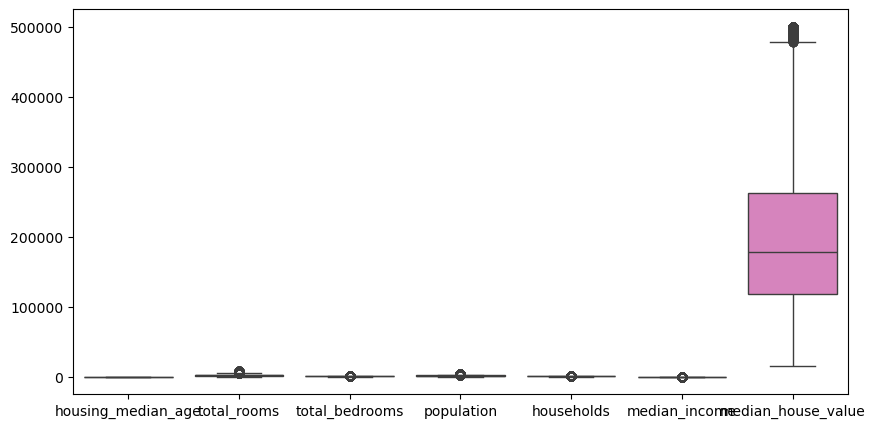

In [19]:
plt.figure(figsize=(10,5))
sns.boxplot(data = data)
plt.show()

In [20]:
# Treating outliers using IQR method
def outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    # Defining bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] > upper_bound) | (df[column] < lower_bound)]
   
    return outliers, upper_bound, lower_bound

In [21]:
for col in selected_columns:
    out,up,low = outliers(data, col)
    if len(out)>0:
        print("Outliers found in",col,"and the count is",len(out))
        data[col] = np.where(data[col] > up, up, data[col])
        data[col] = np.where(data[col] < low, low, data[col])
    else:
        print("No outlier found in", col)


No outlier found in housing_median_age
Outliers found in total_rooms and the count is 801
Outliers found in total_bedrooms and the count is 760
Outliers found in population and the count is 721
Outliers found in households and the count is 716
Outliers found in median_income and the count is 556
Outliers found in median_house_value and the count is 918


In [22]:
data.shape

(19728, 8)

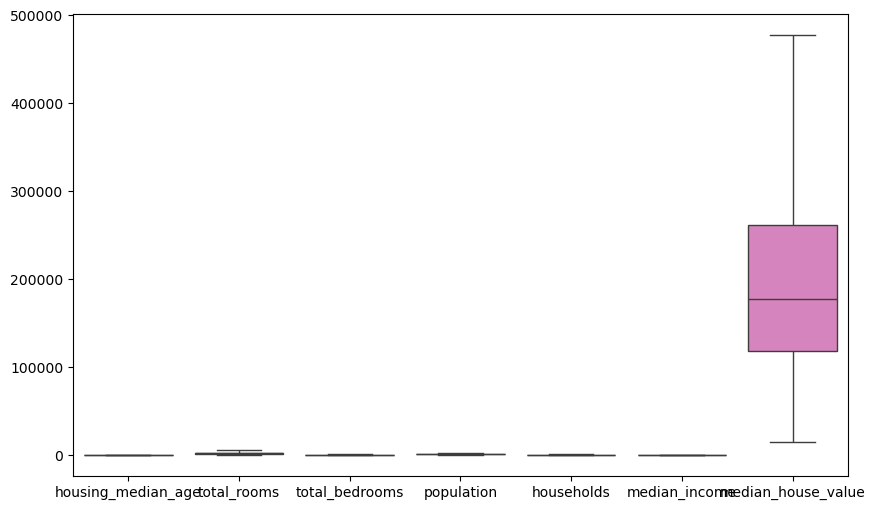

In [23]:
plt.figure(figsize=(10,6))
sns.boxplot(data = data)
plt.show()

In [24]:
ocean_proximity_unique = data['ocean_proximity'].unique()
ocean_proximity_unique

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [25]:
    cat = data.select_dtypes(exclude=np.number).columns.to_list()
    cat


['ocean_proximity']

In [26]:
data[cat].value_counts()

ocean_proximity
<1H OCEAN          8709
INLAND             6257
NEAR OCEAN         2555
NEAR BAY           2202
ISLAND                5
Name: count, dtype: int64

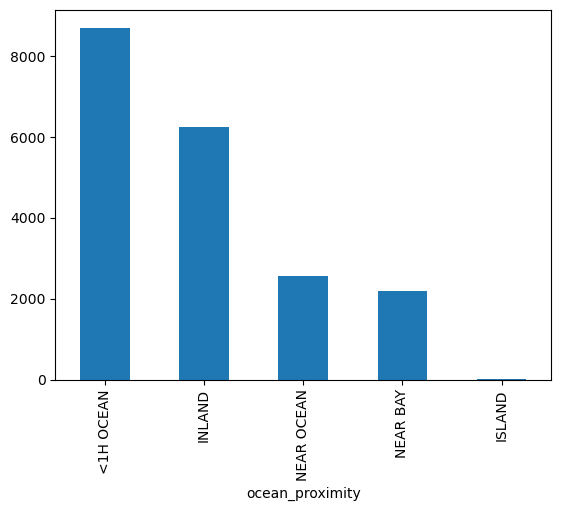

In [27]:
data['ocean_proximity'].value_counts().plot(kind='bar')
plt.show()

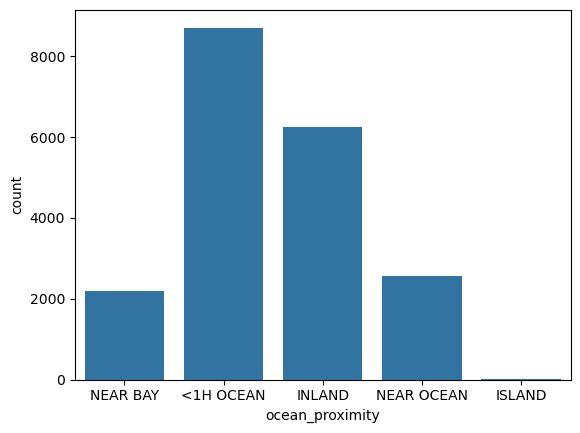

In [28]:
sns.countplot(data=data, x='ocean_proximity')
plt.show()

In [29]:
# map the categorical data
data['ocean_proximity'] = data['ocean_proximity'].map({
    'NEAR BAY': 0, '<1H OCEAN': 1, 'INLAND': 2,  'NEAR OCEAN': 3, 'ISLAND': 4
})

In [30]:
data.head(20)

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,41,880.0,129.0,322.0,126.0,7.906612,0,452600.0
1,21,5338.5,1094.0,2401.0,1026.0,7.906612,0,358500.0
2,52,1467.0,190.0,496.0,177.0,7.257400,0,352100.0
3,52,1274.0,235.0,558.0,219.0,5.643100,0,341300.0
4,52,1627.0,280.0,565.0,259.0,3.846200,0,342200.0
5,52,919.0,213.0,413.0,193.0,4.036800,0,269700.0
6,52,2535.0,489.0,1094.0,514.0,3.659100,0,299200.0
7,52,3104.0,687.0,1157.0,647.0,3.120000,0,241400.0
8,42,2555.0,665.0,1206.0,595.0,2.080400,0,226700.0
9,52,3549.0,707.0,1551.0,714.0,3.691200,0,261100.0


In [31]:
data['ocean_proximity'].value_counts()


ocean_proximity
1    8709
2    6257
3    2555
0    2202
4       5
Name: count, dtype: int64

In [32]:
#input_data = data.drop('median_house_value',axis=1)
input_data = data[['housing_median_age','total_rooms','total_bedrooms','population','households','median_income','ocean_proximity']]
target_data = data['median_house_value']

In [33]:
x_train, x_test, y_train, y_test = train_test_split(input_data, target_data, test_size=0.2, random_state=42)

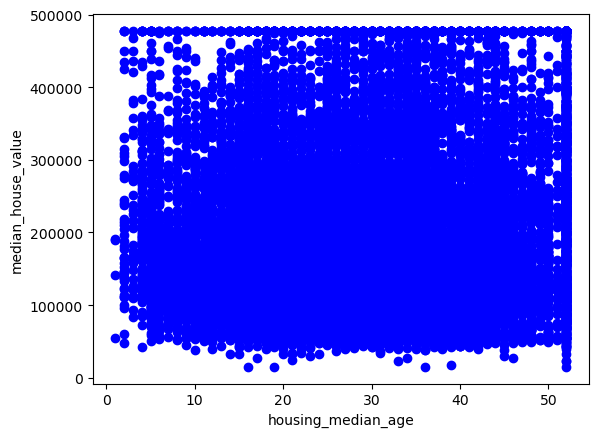

In [34]:
plt.scatter(data.housing_median_age, target_data,  color='blue')
plt.xlabel("housing_median_age")
plt.ylabel("median_house_value")
plt.show()

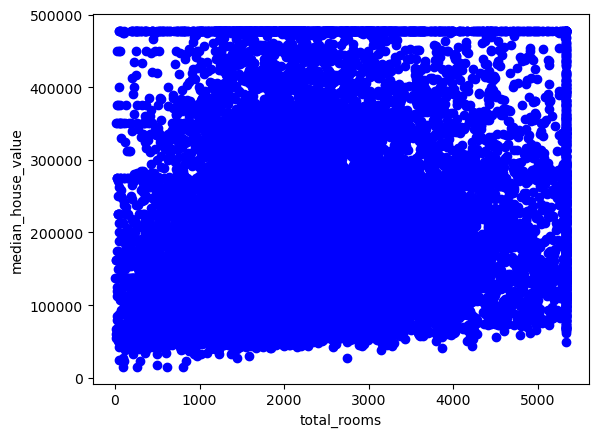

In [35]:
plt.scatter(data.total_rooms, target_data,  color='blue')
plt.xlabel("total_rooms")
plt.ylabel("median_house_value")
plt.show()

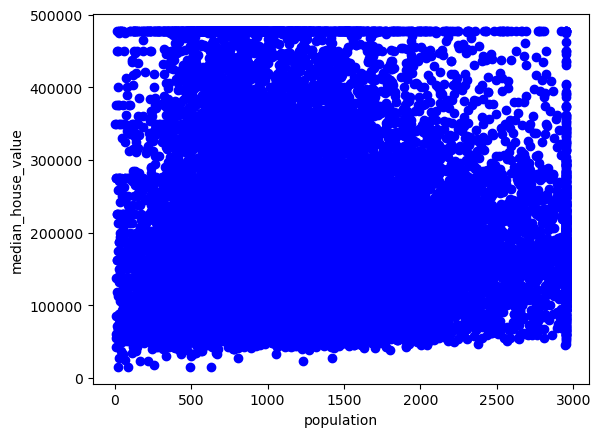

In [36]:
plt.scatter(data.population, target_data,  color='blue')
plt.xlabel("population")
plt.ylabel("median_house_value")
plt.show()

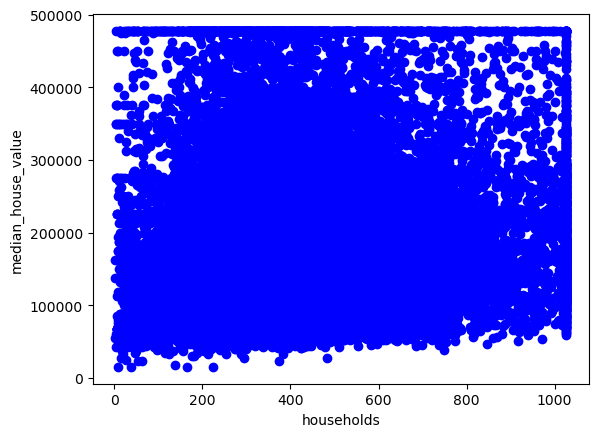

In [37]:
plt.scatter(data.households, target_data,  color='blue')
plt.xlabel("households")
plt.ylabel("median_house_value")
plt.show()

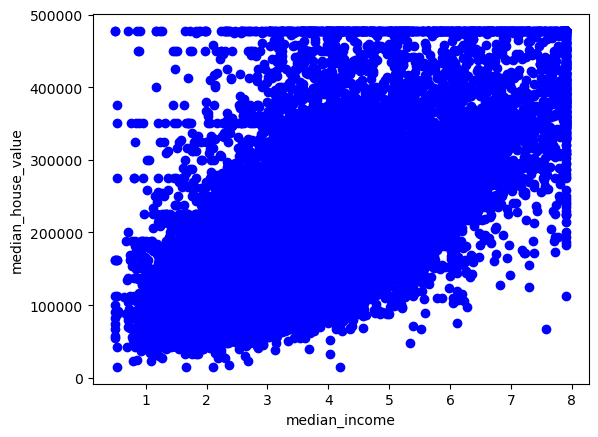

In [38]:
plt.scatter(data.median_income, target_data,  color='blue')
plt.xlabel("median_income")
plt.ylabel("median_house_value")
plt.show()

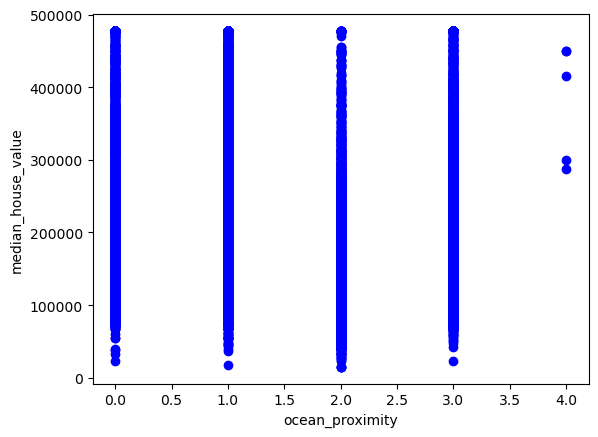

In [39]:
plt.scatter(data.ocean_proximity, target_data,  color='blue')
plt.xlabel("ocean_proximity")
plt.ylabel("median_house_value")
plt.show()

array([[<Axes: title={'center': 'housing_median_age'}>,
        <Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>],
       [<Axes: title={'center': 'population'}>,
        <Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>],
       [<Axes: title={'center': 'ocean_proximity'}>,
        <Axes: title={'center': 'median_house_value'}>, <Axes: >]],
      dtype=object)

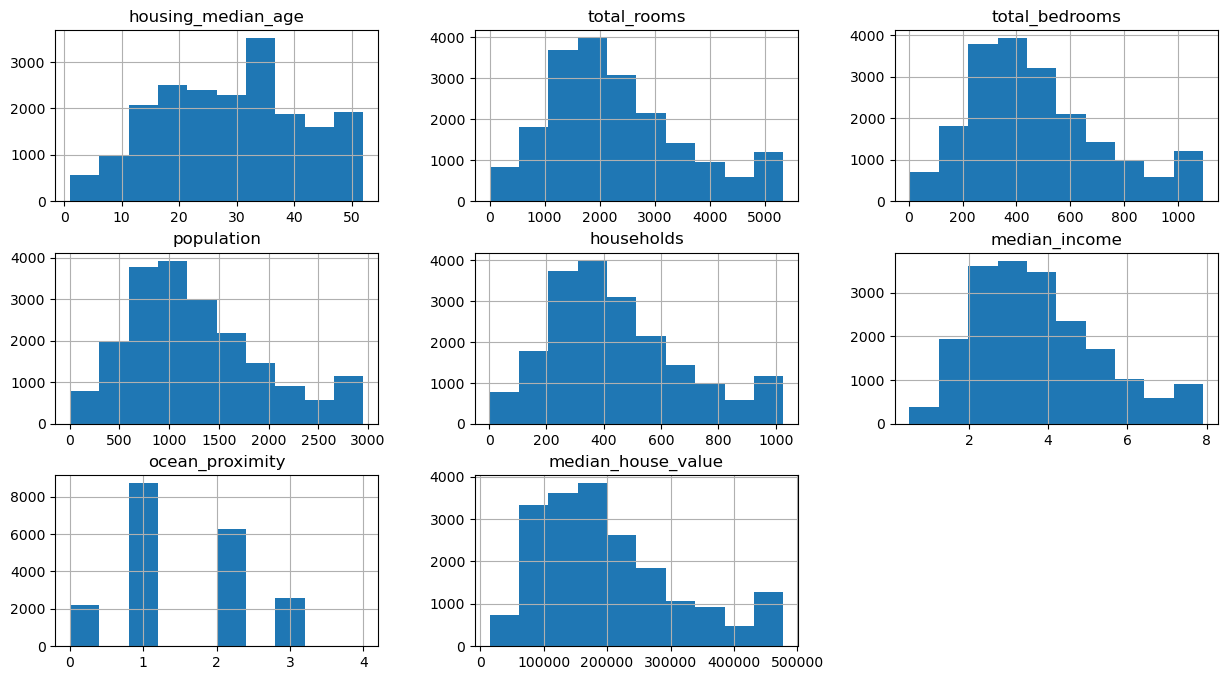

In [40]:
data.hist(figsize=(15,8))

In [42]:
data.corr()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
housing_median_age,1.000000,-0.336498,-0.273633,-0.252098,-0.250914,-0.139780,-0.209729,0.109736
total_rooms,-0.336498,1.000000,0.895820,0.796880,0.893064,0.264514,0.010427,0.186023
total_bedrooms,-0.273633,0.895820,1.000000,0.844680,0.969017,-0.029427,0.002599,0.068862
population,-0.252098,0.796880,0.844680,1.000000,0.885643,-0.015050,-0.023176,-0.039550
households,-0.250914,0.893064,0.969017,0.885643,1.000000,0.005767,-0.023247,0.089579
median_income,-0.139780,0.264514,-0.029427,-0.015050,0.005767,1.000000,-0.142813,0.676830
ocean_proximity,-0.209729,0.010427,0.002599,-0.023176,-0.023247,-0.142813,1.000000,-0.216015
median_house_value,0.109736,0.186023,0.068862,-0.039550,0.089579,0.676830,-0.216015,1.000000


In [43]:
# Define a custom color palette & figure size
custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom", ["red", "orange", "yellow", "green", "blue", "purple", "black"])
plt.figure(figsize=(15,8))

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

<Axes: >

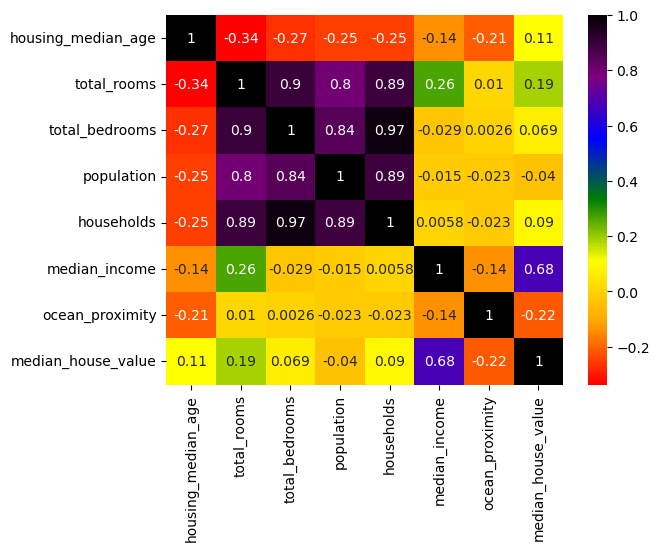

In [44]:
sns.heatmap(data.corr(), annot=True, cmap=custom_cmap)

In [45]:
def met(name,key,arg):
    print('Name of the model: ',name)
    print('R-square of the model:',r2_score(key,arg))
    print('RMSE of the model:',np.sqrt(mean_squared_error(key,arg)))
    print('MAE of the model:',mean_absolute_error(key,arg))

In [46]:
# LinearRegression
regr = LinearRegression()
regr.fit(x_train, y_train)

LinearRegression()

In [47]:
y_pred_lr = regr.predict(x_test)

met('RFE MODEL and result for train',y_test, y_pred_lr)

Name of the model:  RFE MODEL and result for train
R-square of the model: 0.5989451151991557
RMSE of the model: 71199.3692185366
MAE of the model: 52977.265617583784


In [48]:
rf = RandomForestRegressor()
rf.fit(x_train, y_train)

RandomForestRegressor()

In [49]:
y_pred_rf = rf.predict(x_test)
met('RandomForestRegressor model and result for test', y_test, y_pred_rf)

Name of the model:  RandomForestRegressor model and result for test
R-square of the model: 0.7000311004826391
RMSE of the model: 61576.1250902756
MAE of the model: 43597.61082868728


In [50]:
val = [25, 1505, 537.870553, 1392, 359, 1.6812, 2]
predictions = rf.predict([val])
print(int(predictions))

60190


In [51]:
output_lr = pd.DataFrame({'Actual Median House Value': y_test, 'Predicted Median House Value (Linear Regresssion)': y_pred_lr})
output_rf = pd.DataFrame({'Actual Median House Value': y_test, 'Predicted Median House Value (Random Forest)': y_pred_rf})

output_lr.head(10)



,Actual Median House Value,Predicted Median House Value (Linear Regresssion)
9796,477600.0,291571.174602
6374,477600.0,389467.483336
12789,61000.0,119154.817983
8002,203300.0,275399.793831
2709,55200.0,80004.524595
1071,85100.0,166742.688379
2703,61100.0,104677.685803
19760,59200.0,102699.993036
10845,260300.0,255537.317294
10782,325400.0,263592.570312


In [52]:
output_rf.head(10)

,Actual Median House Value,Predicted Median House Value (Random Forest)
9796,477600.0,360595.0
6374,477600.0,454973.0
12789,61000.0,62387.0
8002,203300.0,242924.0
2709,55200.0,70373.0
1071,85100.0,99267.0
2703,61100.0,73090.0
19760,59200.0,102636.0
10845,260300.0,243813.0
10782,325400.0,241344.0


In [53]:
# OLS Regression for more detailed statistics
X_train_const = sm.add_constant(x_train)
ols_model = sm.OLS(y_train, X_train_const).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.592
Model:                            OLS   Adj. R-squared:                  0.592
Method:                 Least Squares   F-statistic:                     3276.
Date:                Sat, 09 Nov 2024   Prob (F-statistic):               0.00
Time:                        18:34:00   Log-Likelihood:            -1.9861e+05
No. Observations:               15782   AIC:                         3.972e+05
Df Residuals:                   15774   BIC:                         3.973e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const              -6.354e+04   3281

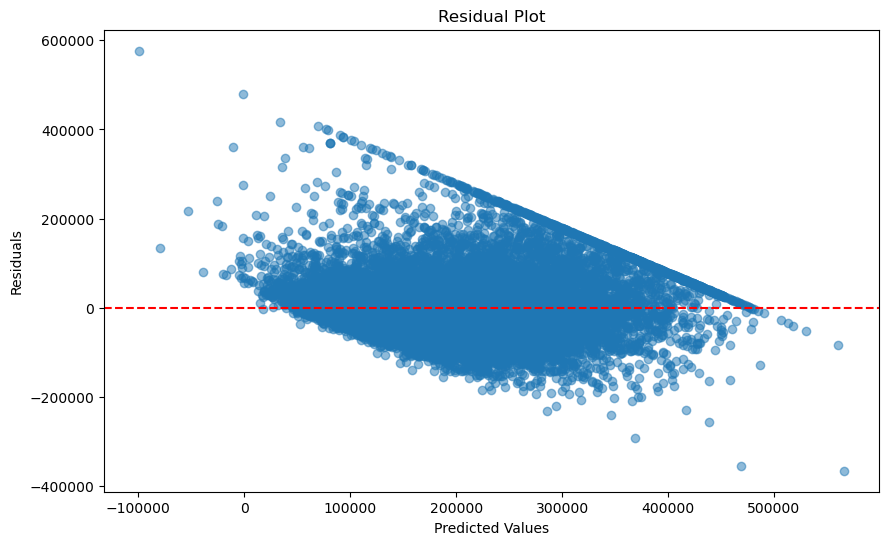

In [54]:
 # Get the predictions and residuals
predictions = ols_model.predict(X_train_const)
residuals = y_train - predictions
    
# Create the residual plot
plt.figure(figsize=(10, 6))
plt.scatter(predictions, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')  # Line at y=0 for reference
plt.title('Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

In [64]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
standardized_data = scaler.fit_transform(input_data)


In [65]:
standardized_data

array([[ 0.95756384, -1.14997669, -1.37504551, ..., -1.35077751,
         2.57255044, -1.71201775],
       [-0.65355911,  2.44068694,  2.44642992, ...,  2.46258579,
         2.57255044, -1.71201775],
       [ 1.84368146, -0.67723484, -1.13348074, ..., -1.13468692,
         2.17054422, -1.71201775],
       ...,
       [-0.9757837 , -0.04342251,  0.03474232, ..., -0.04999691,
        -1.27071635,  0.62468394],
       [-0.89522755, -0.36073135, -0.26622362, ..., -0.40591082,
        -1.16718254,  0.62468394],
       [-1.05633985,  0.38421961,  0.55351256, ...,  0.36099891,
        -0.84432054,  0.62468394]])

In [56]:
x_train, x_test, y_train, y_test = train_test_split(standardized_data, target_data, test_size=0.2, random_state=42)

In [57]:
regr.fit(x_train, y_train)

LinearRegression()

In [58]:
y_pred_lr = regr.predict(x_test)

met('RFE MODEL and result for train',y_test, y_pred_lr)

Name of the model:  RFE MODEL and result for train
R-square of the model: 0.5989451151991553
RMSE of the model: 71199.36921853664
MAE of the model: 52977.2656175838


In [61]:
rf.fit(x_train, y_train)

RandomForestRegressor()

In [62]:
y_pred_rf = rf.predict(x_test)
met('RandomForestRegressor model and result for test', y_test, y_pred_rf)

Name of the model:  RandomForestRegressor model and result for test
R-square of the model: 0.6988311413704944
RMSE of the model: 61699.162988480915
MAE of the model: 43754.87085656361


In [63]:
output_lr = pd.DataFrame({'Actual Median House Value': y_test, 'Predicted Median House Value (Linear Regresssion)': y_pred_lr})
output_rf = pd.DataFrame({'Actual Median House Value': y_test, 'Predicted Median House Value (Random Forest)': y_pred_rf})

output_lr.head(10)


,Actual Median House Value,Predicted Median House Value (Linear Regresssion)
9796,477600.0,291571.174602
6374,477600.0,389467.483336
12789,61000.0,119154.817983
8002,203300.0,275399.793831
2709,55200.0,80004.524595
1071,85100.0,166742.688379
2703,61100.0,104677.685803
19760,59200.0,102699.993036
10845,260300.0,255537.317294
10782,325400.0,263592.570312


In [66]:
# OLS Regression for more detailed statistics
X_train_const = sm.add_constant(x_train)
ols_model = sm.OLS(y_train, X_train_const).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.592
Model:                            OLS   Adj. R-squared:                  0.592
Method:                 Least Squares   F-statistic:                     3276.
Date:                Sat, 09 Nov 2024   Prob (F-statistic):               0.00
Time:                        18:44:24   Log-Likelihood:            -1.9861e+05
No. Observations:               15782   AIC:                         3.972e+05
Df Residuals:                   15774   BIC:                         3.973e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.036e+05    562.774    361.737      0.0

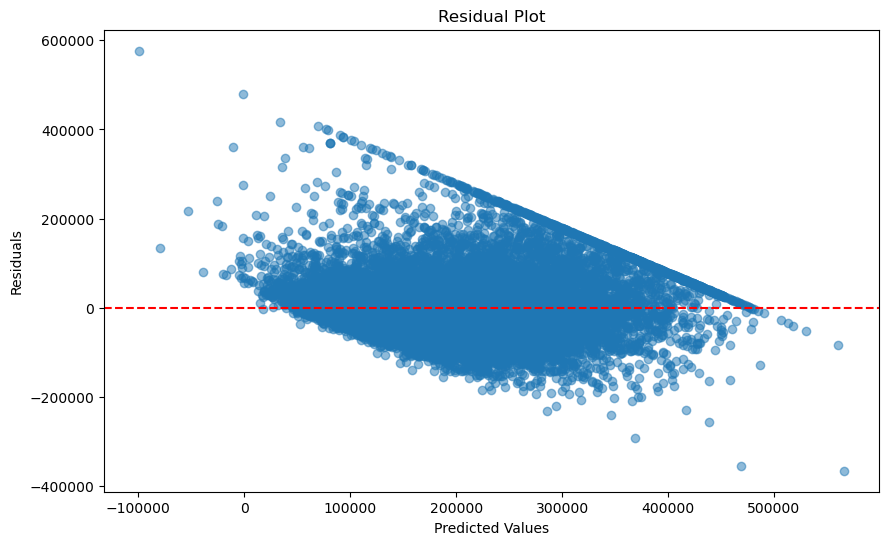

In [67]:
 # Get the predictions and residuals
predictions = ols_model.predict(X_train_const)
residuals = y_train - predictions
    
# Create the residual plot
plt.figure(figsize=(10, 6))
plt.scatter(predictions, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')  # Line at y=0 for reference
plt.title('Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

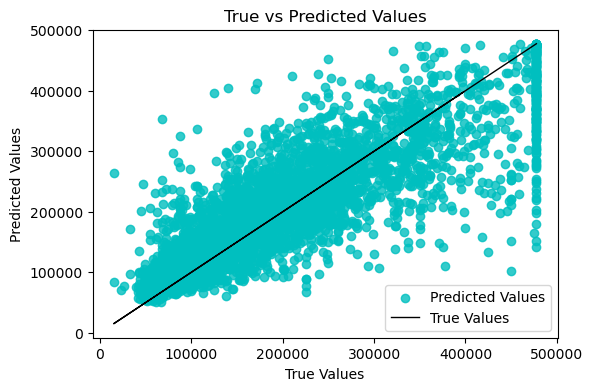

In [70]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(y_test, y_pred_rf, c="c", alpha=0.8, label="Predicted Values")

ax.plot(y_test, y_test, c="k", lw=1, label="True Values")

ax.set_xlabel('True Values')
ax.set_ylabel('Predicted Values')
ax.set_title('True vs Predicted Values')
ax.legend()